# Stock Technical Analysis Tool
## RSI, MACD, and Fibonacci Retracement Analysis

This notebook performs comprehensive technical analysis on stocks using:
- **RSI (Relative Strength Index)** - Momentum indicator
- **MACD (Moving Average Convergence Divergence)** - Trend indicator
- **Fibonacci Retracement** - Support/Resistance levels

---

In [13]:
# import sys
# print(sys.executable)

In [14]:
# import yfinance
# print(yfinance.__version__)

## 1. Configuration
Set your stock ticker, time period, and data interval here:

In [15]:
# ============================================================================
# CONFIGURATION - CHANGE THESE VALUES
# ============================================================================
TICKER = "IAU"        # Stock ticker symbol (e.g., "BTC-USD", "GC=F", "IBIT", "^GSPC")
PERIOD = "1y"         # Time period: "1d", "5d", "1mo", "3mo", "6mo", "1y", "2y", "5y", "max"
INTERVAL = "1d"       # Data interval: "1m", "5m", "15m", "1h", "1d", "1wk", "1mo"
# ============================================================================

## 2. Import Libraries
Load all required libraries for data fetching, analysis, and visualization:

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 3. Define Technical Indicator Functions
Functions to calculate RSI, MACD, and other indicators:

In [17]:
def calculate_rsi(data, period=14):
    """Calculate Relative Strength Index (RSI)"""
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_macd(data, fast=12, slow=26, signal=9):
    """Calculate MACD (Moving Average Convergence Divergence)"""
    ema_fast = data.ewm(span=fast, adjust=False).mean()
    ema_slow = data.ewm(span=slow, adjust=False).mean()
    
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    
    return macd_line, signal_line, histogram

print("✅ Indicator functions defined!")

✅ Indicator functions defined!


## 4. Download Stock Data
Fetch historical stock data from Yahoo Finance:

In [18]:
print(f"Downloading {TICKER} data...")
print(f"Period: {PERIOD} | Interval: {INTERVAL}\n")

try:
    stock = yf.Ticker(TICKER)
    df = stock.history(period=PERIOD, interval=INTERVAL)
    
    if df.empty:
        raise ValueError(f"No data found for {TICKER}")
    
    print(f"✅ Successfully downloaded {len(df)} data points")
    print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}\n")
    
    # Create display DataFrame with selected columns and formatting
    display_df = df[['High', 'Low', 'Close']].tail(10).copy()
    
    # Round to whole numbers
    display_df['High'] = display_df['High'].round(0).astype(int)
    display_df['Low'] = display_df['Low'].round(0).astype(int)
    display_df['Close'] = display_df['Close'].round(0).astype(int)
    
    # Calculate percentage change from prior close
    display_df['% Change'] = df['Close'].pct_change().tail(10) * 100
    display_df['% Change'] = display_df['% Change'].round(2)
    
    # Format index to show date only
    display_df.index = display_df.index.strftime('%Y-%m-%d')
    
    print("Last 10 Trading Days:")
    display(display_df)
    
except Exception as e:
    print(f"❌ Error downloading data: {e}")

Period: 1y | Interval: 1d

✅ Successfully downloaded 251 data points
Date range: 2025-03-03 to 2026-03-02

Last 10 Trading Days:


,High,Low,Close,% Change
Date,,,,
2026-02-17,92,91,92,-3.09
2026-02-18,94,93,94,2.21
2026-02-19,95,93,94,0.29
2026-02-20,96,94,96,1.94
2026-02-23,99,97,99,2.73
2026-02-24,97,96,97,-1.39
2026-02-25,98,97,97,-0.24
2026-02-26,98,97,98,0.85
2026-02-27,99,98,99,1.31


## 5. Calculate Technical Indicators
Calculate RSI, MACD, Moving Averages, and Fibonacci levels:

In [19]:
# Calculate indicators
df['RSI'] = calculate_rsi(df['Close'])
df['MACD'], df['Signal'], df['Histogram'] = calculate_macd(df['Close'])
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Calculate Fibonacci levels
max_price = df['Close'].max()
min_price = df['Close'].min()
max_date = df['Close'].idxmax()
min_date = df['Close'].idxmin()

# Determine trend direction
if min_date < max_date:
    trend_direction = "UPTREND"
else:
    trend_direction = "DOWNTREND"

# Calculate Fibonacci retracement levels
diff = max_price - min_price
fib_levels = {
    '0%': max_price,
    '23.6%': max_price - (diff * 0.236),
    '38.2%': max_price - (diff * 0.382),
    '50%': max_price - (diff * 0.500),
    '61.8%': max_price - (diff * 0.618),
    '78.6%': max_price - (diff * 0.786),
    '100%': min_price
}

print("✅ All indicators calculated successfully!\n")
print(f"Current Price: ${df['Close'].iloc[-1]:.2f}")
print(f"RSI: {df['RSI'].iloc[-1]:.2f}")
print(f"MACD: {df['MACD'].iloc[-1]:.4f}")
print(f"Trend: {trend_direction}")

✅ All indicators calculated successfully!

Current Price: $100.48
RSI: 60.87
MACD: 2.3604
Trend: UPTREND


## 6. Chart 1: Price with Moving Averages, RSI, and MACD
Three-panel chart showing price action, momentum, and trend:

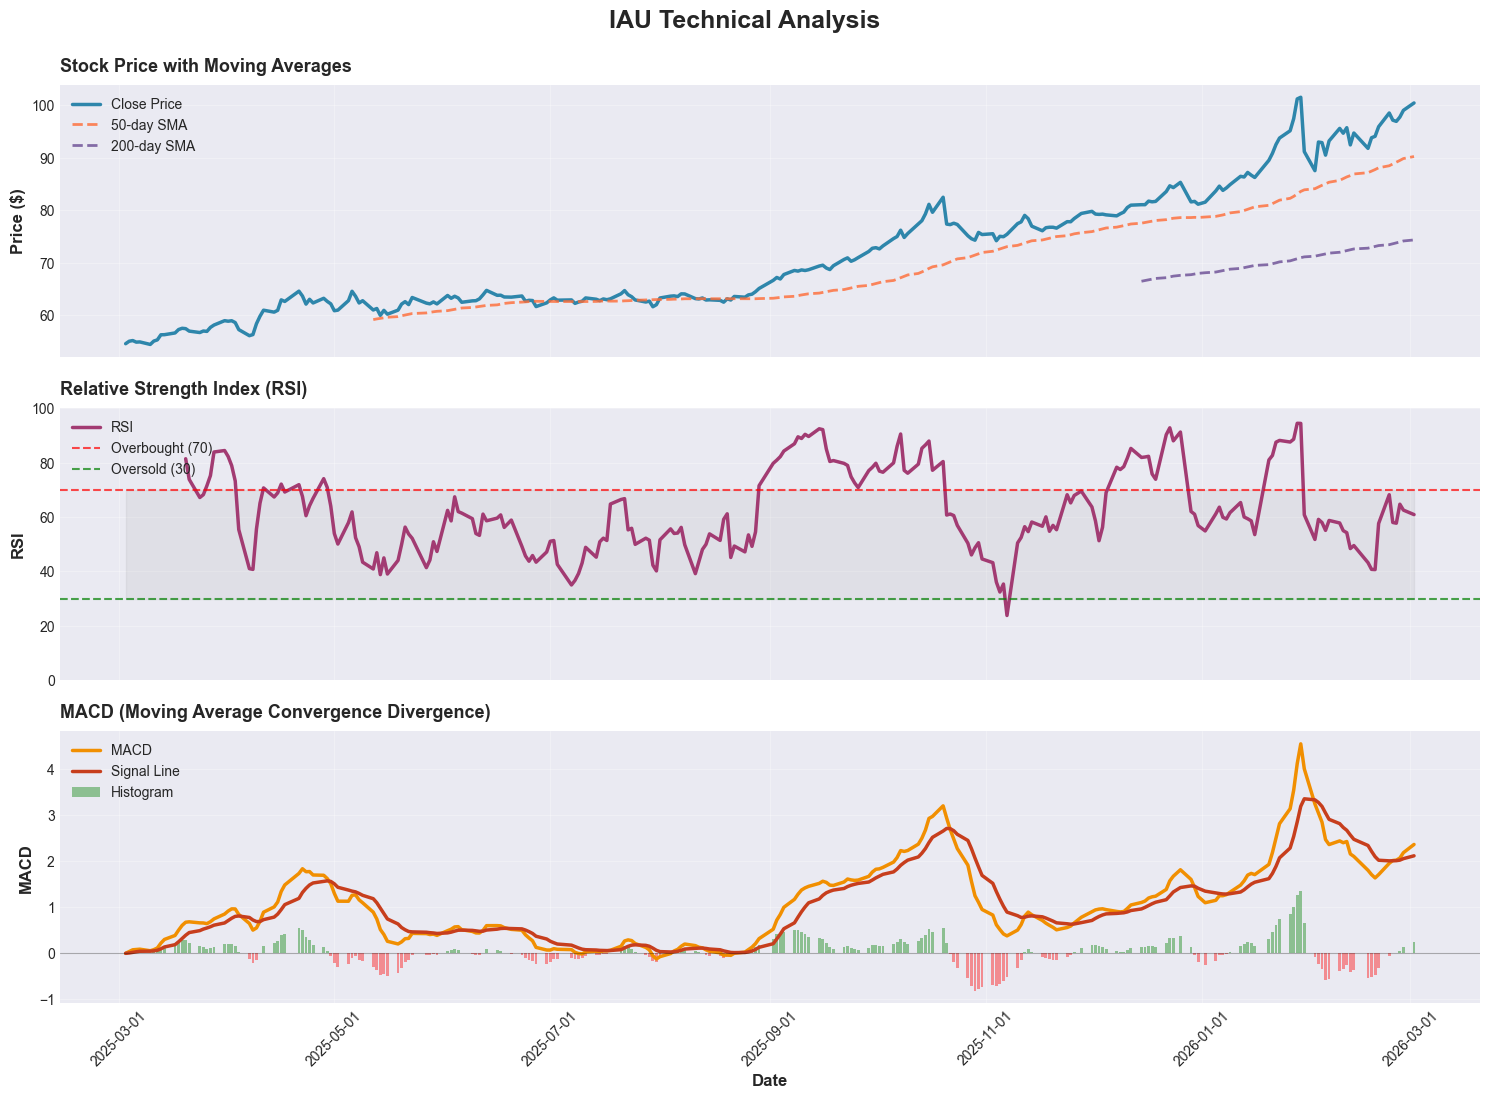

In [20]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
fig.suptitle(f'{TICKER} Technical Analysis', fontsize=18, fontweight='bold', y=0.995)

# Plot 1: Price with moving averages
ax1.plot(df.index, df['Close'], label='Close Price', color='#2E86AB', linewidth=2.5)
ax1.plot(df.index, df['SMA_50'], label='50-day SMA', color='#FF6B35', linewidth=2, linestyle='--', alpha=0.8)
ax1.plot(df.index, df['SMA_200'], label='200-day SMA', color='#6A4C93', linewidth=2, linestyle='--', alpha=0.8)
ax1.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_title('Stock Price with Moving Averages', fontsize=13, fontweight='bold', loc='left', pad=10)

# Plot 2: RSI
ax2.plot(df.index, df['RSI'], label='RSI', color='#A23B72', linewidth=2.5)
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Oversold (30)')
ax2.fill_between(df.index, 30, 70, alpha=0.1, color='gray')
ax2.set_ylabel('RSI', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_title('Relative Strength Index (RSI)', fontsize=13, fontweight='bold', loc='left', pad=10)

# Plot 3: MACD with colored histogram
ax3.plot(df.index, df['MACD'], label='MACD', color='#F18F01', linewidth=2.5)
ax3.plot(df.index, df['Signal'], label='Signal Line', color='#C73E1D', linewidth=2.5)

# Color histogram bars: green for positive, red for negative
colors = ['green' if val >= 0 else 'red' for val in df['Histogram']]
ax3.bar(df.index, df['Histogram'], label='Histogram', color=colors, alpha=0.4)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.8)
ax3.set_ylabel('MACD', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_title('MACD (Moving Average Convergence Divergence)', fontsize=13, fontweight='bold', loc='left', pad=10)
ax3.set_xlabel('Date', fontsize=12, fontweight='bold')

# Format x-axis
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 7. Chart 2: Fibonacci Retracement Levels
Price chart with Fibonacci support/resistance levels:

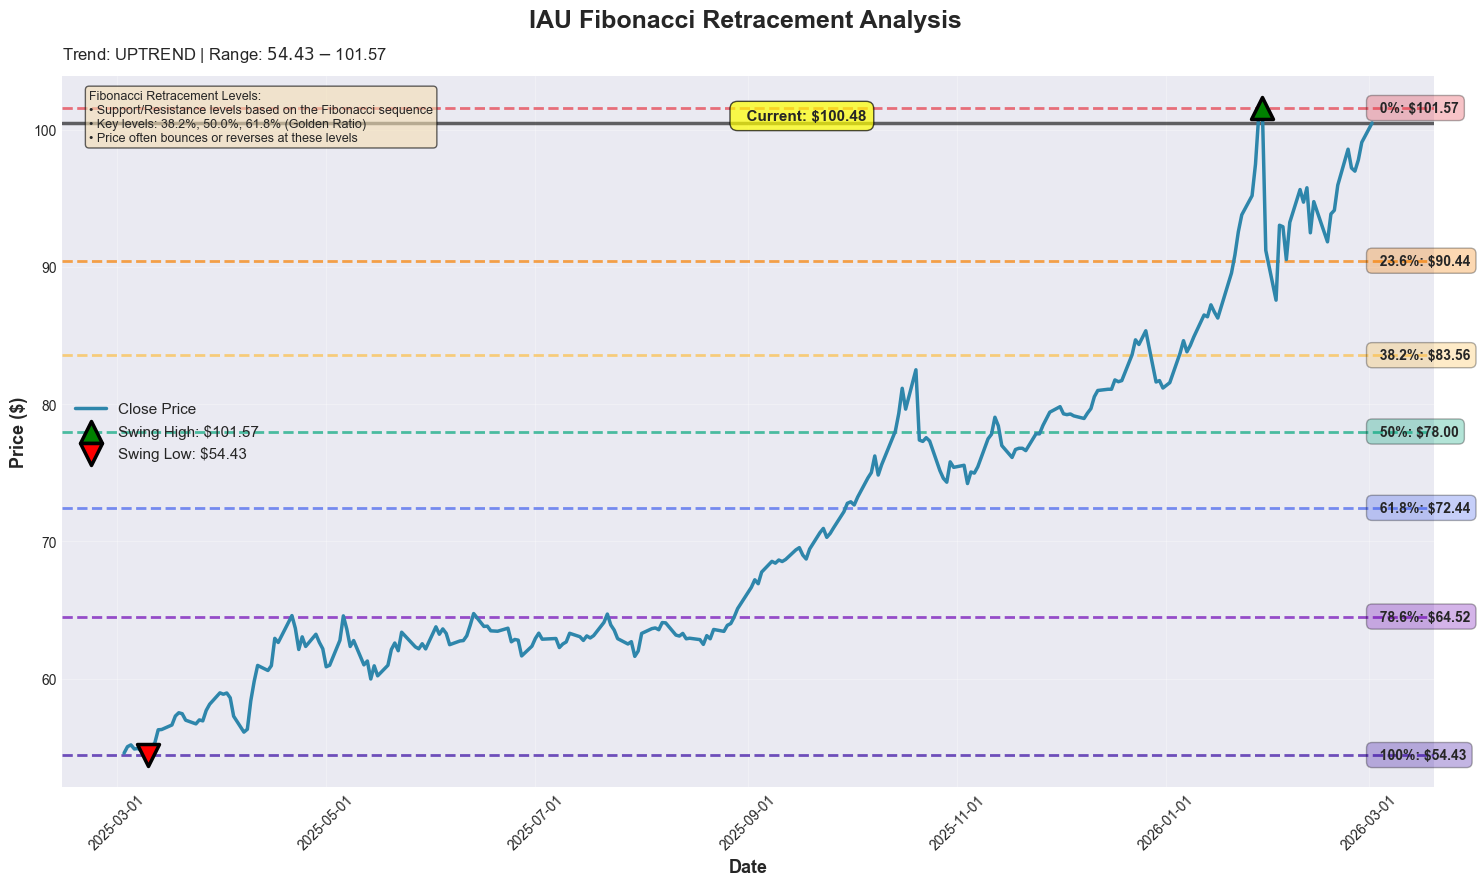

In [21]:
fig, ax = plt.subplots(figsize=(15, 9))
fig.suptitle(f'{TICKER} Fibonacci Retracement Analysis', fontsize=18, fontweight='bold')

# Plot the price
ax.plot(df.index, df['Close'], label='Close Price', color='#2E86AB', linewidth=2.5, zorder=5)

# Plot Fibonacci levels
colors = ['#E63946', '#F77F00', '#FCBF49', '#06A77D', '#4361EE', '#7209B7', '#3A0CA3']
for (level_name, level_price), color in zip(fib_levels.items(), colors):
    ax.axhline(y=level_price, color=color, linestyle='--', alpha=0.7, linewidth=2)
    ax.text(df.index[-1], level_price, f'  {level_name}: ${level_price:.2f}', 
            verticalalignment='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.3))

# Mark the swing high and swing low points
ax.scatter([max_date], [max_price], color='green', s=250, zorder=10, 
           marker='^', edgecolors='black', linewidth=2.5, label=f'Swing High: ${max_price:.2f}')
ax.scatter([min_date], [min_price], color='red', s=250, zorder=10, 
           marker='v', edgecolors='black', linewidth=2.5, label=f'Swing Low: ${min_price:.2f}')

# Add current price line
current_price = df['Close'].iloc[-1]
ax.axhline(y=current_price, color='black', linestyle='-', alpha=0.6, linewidth=2.5)
ax.text(df.index[len(df)//2], current_price, f'  Current: ${current_price:.2f}', 
        verticalalignment='bottom', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.set_ylabel('Price ($)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_title(f'Trend: {trend_direction} | Range: ${min_price:.2f} - ${max_price:.2f}', 
             fontsize=12, loc='left', pad=12)

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Add explanation text
explanation = (
    "Fibonacci Retracement Levels:\n"
    "• Support/Resistance levels based on the Fibonacci sequence\n"
    "• Key levels: 38.2%, 50.0%, 61.8% (Golden Ratio)\n"
    "• Price often bounces or reverses at these levels"
)
ax.text(0.02, 0.98, explanation, transform=ax.transAxes, 
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.show()

## 8. Signal Analysis
Analyze indicators and generate buy/sell/hold signals:

In [22]:
# Get latest values
latest = df.iloc[-1]
previous = df.iloc[-2]

current_price = latest['Close']
rsi = latest['RSI']
macd = latest['MACD']
signal = latest['Signal']
histogram = latest['Histogram']
prev_histogram = previous['Histogram']

print("="*70)
print(f"SIGNAL ANALYSIS: {TICKER}")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

print(f"\nCurrent Price: ${current_price:.2f}\n")

# RSI Analysis
print("📊 RSI ANALYSIS:")
print("-" * 70)
if rsi < 30:
    rsi_signal = "OVERSOLD - Potential BUY signal"
    rsi_score = 1
elif rsi > 70:
    rsi_signal = "OVERBOUGHT - Potential SELL signal"
    rsi_score = -1
elif rsi < 40:
    rsi_signal = "Approaching oversold - Cautiously bullish"
    rsi_score = 0.5
elif rsi > 60:
    rsi_signal = "Approaching overbought - Cautiously bearish"
    rsi_score = -0.5
else:
    rsi_signal = "NEUTRAL - No strong signal"
    rsi_score = 0

print(f"RSI Value: {rsi:.2f}")
print(f"Signal: {rsi_signal}")
print(f"Score: {rsi_score:+.2f}")

# MACD Analysis
print("\n📈 MACD ANALYSIS:")
print("-" * 70)
if macd > signal and prev_histogram < 0 and histogram > 0:
    macd_signal = "BULLISH CROSSOVER - Strong BUY signal"
    macd_score = 1
elif macd < signal and prev_histogram > 0 and histogram < 0:
    macd_signal = "BEARISH CROSSOVER - Strong SELL signal"
    macd_score = -1
elif macd > signal:
    macd_signal = "MACD above signal - Bullish momentum"
    macd_score = 0.5
elif macd < signal:
    macd_signal = "MACD below signal - Bearish momentum"
    macd_score = -0.5
else:
    macd_signal = "NEUTRAL - No clear signal"
    macd_score = 0

print(f"MACD: {macd:.4f}")
print(f"Signal Line: {signal:.4f}")
print(f"Histogram: {histogram:.4f}")
print(f"Signal: {macd_signal}")
print(f"Score: {macd_score:+.2f}")

# Fibonacci Analysis
print("\n📐 FIBONACCI ANALYSIS:")
print("-" * 70)

tolerance = current_price * 0.02
fib_score = 0
fib_signal = ""

if trend_direction == "UPTREND":
    if abs(current_price - fib_levels['38.2%']) < tolerance:
        fib_signal = "Near 38.2% support - STRONG BUY zone"
        fib_score = 1
    elif abs(current_price - fib_levels['50%']) < tolerance:
        fib_signal = "Near 50% support - BUY zone"
        fib_score = 0.75
    elif abs(current_price - fib_levels['61.8%']) < tolerance:
        fib_signal = "Near 61.8% (Golden Ratio) support - CRITICAL BUY zone"
        fib_score = 1
    elif current_price > fib_levels['23.6%']:
        fib_signal = "Above 23.6% - Strong uptrend continuation"
        fib_score = 0.5
    elif current_price < fib_levels['61.8%']:
        fib_signal = "Below 61.8% - Weak support, caution"
        fib_score = -0.5
    else:
        fib_signal = "Between support levels - NEUTRAL"
        fib_score = 0
else:
    if abs(current_price - fib_levels['38.2%']) < tolerance:
        fib_signal = "Near 38.2% resistance - STRONG SELL zone"
        fib_score = -1
    elif abs(current_price - fib_levels['50%']) < tolerance:
        fib_signal = "Near 50% resistance - SELL zone"
        fib_score = -0.75
    elif abs(current_price - fib_levels['61.8%']) < tolerance:
        fib_signal = "Near 61.8% (Golden Ratio) resistance - CRITICAL SELL zone"
        fib_score = -1
    elif current_price < fib_levels['61.8%']:
        fib_signal = "Below 61.8% - Strong downtrend continuation"
        fib_score = -0.5
    elif current_price > fib_levels['38.2%']:
        fib_signal = "Above 38.2% - Weak resistance, possible reversal"
        fib_score = 0.5
    else:
        fib_signal = "Between resistance levels - NEUTRAL"
        fib_score = 0

print(f"Trend: {trend_direction}")
print(f"Range: ${min_price:.2f} - ${max_price:.2f}")
print(f"Signal: {fib_signal}")
print(f"Score: {fib_score:+.2f}")

print("\n" + "="*70)

SIGNAL ANALYSIS: IAU
Analysis Date: 2026-03-02 12:49:00

Current Price: $100.48

📊 RSI ANALYSIS:
----------------------------------------------------------------------
RSI Value: 60.87
Signal: Approaching overbought - Cautiously bearish
Score: -0.50

📈 MACD ANALYSIS:
----------------------------------------------------------------------
MACD: 2.3604
Signal Line: 2.1144
Histogram: 0.2461
Signal: MACD above signal - Bullish momentum
Score: +0.50

📐 FIBONACCI ANALYSIS:
----------------------------------------------------------------------
Trend: UPTREND
Range: $54.43 - $101.57
Signal: Above 23.6% - Strong uptrend continuation
Score: +0.50



## 9. Final Recommendation
Combined analysis and trading recommendation:

In [23]:
# Calculate total score
total_score = rsi_score + macd_score + fib_score

print("\n" + "="*70)
print("TRADING RECOMMENDATION")
print("="*70)

if total_score >= 2:
    recommendation = "🟢 STRONG BUY"
    explanation = "RSI, MACD, and Fibonacci indicators are showing strong bullish signals."
elif total_score >= 1:
    recommendation = "🟢 BUY"
    explanation = "Indicators are leaning bullish. Consider entering a position."
elif total_score >= 0.5:
    recommendation = "🟡 LEAN BUY"
    explanation = "Slightly bullish signals. Wait for confirmation or enter with caution."
elif total_score <= -2:
    recommendation = "🔴 STRONG SELL"
    explanation = "RSI, MACD, and Fibonacci indicators are showing strong bearish signals."
elif total_score <= -1:
    recommendation = "🔴 SELL"
    explanation = "Indicators are leaning bearish. Consider taking profits or exiting."
elif total_score <= -0.5:
    recommendation = "🟡 LEAN SELL"
    explanation = "Slightly bearish signals. Consider reducing position or wait for confirmation."
else:
    recommendation = "🟡 HOLD"
    explanation = "Mixed or neutral signals. Wait for clearer indicators before acting."

print(f"\n{recommendation}\n")
print(f"Signal Score: {total_score:.2f}/3.0")
print(f"  • RSI: {rsi_score:+.2f}")
print(f"  • MACD: {macd_score:+.2f}")
print(f"  • Fibonacci: {fib_score:+.2f}")
print(f"\n{explanation}")




TRADING RECOMMENDATION

🟡 LEAN BUY

Signal Score: 0.50/3.0
  • RSI: -0.50
  • MACD: +0.50
  • Fibonacci: +0.50

Slightly bullish signals. Wait for confirmation or enter with caution.


## 10. Summary Table
Quick reference table of all key metrics:

In [24]:
# Create summary DataFrame
summary_data = {
    'Metric': ['Current Price', 'RSI (14)', 'MACD', 'Signal Line', 'Histogram', 
               '50-day SMA', '200-day SMA', 'Trend', 'Swing High', 'Swing Low'],
    'Value': [
        f"${current_price:.2f}",
        f"{rsi:.2f}",
        f"{macd:.4f}",
        f"{signal:.4f}",
        f"{histogram:.4f}",
        f"${df['SMA_50'].iloc[-1]:.2f}" if not pd.isna(df['SMA_50'].iloc[-1]) else 'N/A',
        f"${df['SMA_200'].iloc[-1]:.2f}" if not pd.isna(df['SMA_200'].iloc[-1]) else 'N/A',
        trend_direction,
        f"${max_price:.2f}",
        f"${min_price:.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

print("\n📊 Analysis Complete!")

,Metric,Value
0,Current Price,$100.48
1,RSI (14),60.87
2,MACD,2.3604
3,Signal Line,2.1144
4,Histogram,0.2461
5,50-day SMA,$90.27
6,200-day SMA,$74.36
7,Trend,UPTREND
8,Swing High,$101.57
9,Swing Low,$54.43



📊 Analysis Complete!
